# Notebook 01: Baseline Replication

**Goal:** Replicate the induction circuit in the pretrained `attn-only-2l` model.

**Outputs:** `experiments/results/baseline_induction_scores.npz`, `paper/figures/fig3_*`

**Runtime:** ~5 minutes on CPU.

In [2]:
import os

repo_url = 'https://github.com/Mattral/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning.git'
repo_name = 'Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning'

# Clone the repository if it doesn't already exist
if not os.path.exists(repo_name):
    print(f"Cloning {repo_url}...")
    !git clone {repo_url}
    print("Repository cloned.")
else:
    print(f"Repository '{repo_name}' already exists.")

# Change directory to the cloned repository
# This changes the current working directory for this cell and subsequent cells.
%cd /content/{repo_name}

# Completely purge existing torch/numpy and hidden cache files
print("Uninstalling existing Python packages...")
!pip uninstall -y torch torchvision torchaudio numpy
!rm -rf /usr/local/lib/python3.12/dist-packages/~*

# Perform a fresh installation of compatible versions
print("Installing compatible versions of required packages...")
!pip install "numpy>=2.0,<2.1" "torch>=2.4.0" "transformers>=4.44.0" "transformer_lens" --quiet

print("\nEnvironment setup complete. You MUST now go to Runtime -> Restart session for changes to take effect and proceed with the notebook execution.")

Cloning https://github.com/Mattral/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning.git...
Cloning into 'Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning'...
remote: Enumerating objects: 1087, done.
remote: Counting objects: 100% (295/295), done.
remote: Compressing objects: 100% (195/195), done.
remote: Total 1087 (delta 158), reused 188 (delta 90), pack-reused 792 (from 1)
Receiving objects: 100% (1087/1087), 3.66 MiB | 10.45 MiB/s, done.
Resolving deltas: 100% (540/540), done.
Filtering content: 100% (2/2), 206.61 MiB | 14.77 MiB/s, done.
Repository cloned.
/content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning
Uninstalling existing Python packages...
Found existing installation: torch 2.7.1
Uninstalling torch-2.7.1:
  Successfully uninstalled torch-2.7.1
Found existing installation: torchvision 0.22.1
Uninstalling torchvision-0.22.1:
  Successfully uninstalled torchvision-0.22.1
Found

### Action Required: Restart Runtime

Please go to `Runtime` -> `Restart session` in the Colab menu.

After restarting, please re-run the cells below to ensure all necessary modules are correctly imported and the `sys.path` is properly configured.

In [1]:
import sys
import os
from pathlib import Path

# Set absolute path to repo root
repo_root = "/content/Mechanistic-Interpretability-Study-Induction-Circuit-Stability-Under-Fine-Tuning"
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.circuits.induction_score import compute_induction_score_with_stats, identify_induction_heads
from src.viz.attention_vis import plot_induction_score_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')
print("Modules imported successfully from src.")

Device: cuda
Modules imported successfully from src.


In [2]:
import sys; sys.path.insert(0, '..')
import numpy as np, torch, matplotlib.pyplot as plt
from pathlib import Path
from src.model.config import ModelConfig, EvalConfig
from src.model.train import load_pretrained_model, set_global_seed
from src.circuits.induction_score import compute_induction_score_with_stats, identify_induction_heads
from src.viz.attention_vis import plot_induction_score_heatmap

set_global_seed(42)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


In [3]:
model_config = ModelConfig()
eval_config = EvalConfig()
model = load_pretrained_model(model_config, device=device)
print(f'Loaded: {model_config.source} | {model.cfg.n_layers}L {model.cfg.n_heads}H')

config.json:   0%|          | 0.00/1.28k [00:00<?, ?B/s]

./model_final.pth:   0%|          | 0.00/210M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.04M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/81.0 [00:00<?, ?B/s]

Loaded pretrained model attn-only-2l into HookedTransformer
Moving model to device:  cuda
Loaded: attn-only-2l | 2L 8H


In [4]:
means, stds = compute_induction_score_with_stats(
    model=model, sequence_length=eval_config.induction_seq_length,
    num_sequences=eval_config.induction_num_sequences, seed=eval_config.seed, device=device,
)
heads = identify_induction_heads(means, threshold=0.5)
print('Induction heads (>=0.5):', heads)
for l in range(model.cfg.n_layers):
    for h in range(model.cfg.n_heads):
        print(f'  L{l}H{h}: {means[l,h]:.3f} +/- {stds[l,h]:.3f}')

Induction heads (>=0.5): []
  L0H0: 0.001 +/- 0.000
  L0H1: 0.001 +/- 0.000
  L0H2: 0.004 +/- 0.001
  L0H3: 0.001 +/- 0.000
  L0H4: 0.005 +/- 0.001
  L0H5: 0.001 +/- 0.000
  L0H6: 0.004 +/- 0.001
  L0H7: 0.003 +/- 0.001
  L1H0: 0.006 +/- 0.003
  L1H1: 0.000 +/- 0.001
  L1H2: 0.001 +/- 0.002
  L1H3: 0.003 +/- 0.003
  L1H4: 0.000 +/- 0.001
  L1H5: 0.004 +/- 0.004
  L1H6: 0.408 +/- 0.103
  L1H7: 0.033 +/- 0.005


In [5]:
results_dir = Path('../experiments/results'); results_dir.mkdir(parents=True, exist_ok=True)
np.savez(results_dir / 'baseline_induction_scores.npz',
         means=means.cpu().numpy(), stds=stds.cpu().numpy(),
         induction_heads=np.array(heads))
print('Saved.')

Saved.


In [6]:
from google.colab import files

file_path = results_dir / 'baseline_induction_scores.npz'
files.download(file_path)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

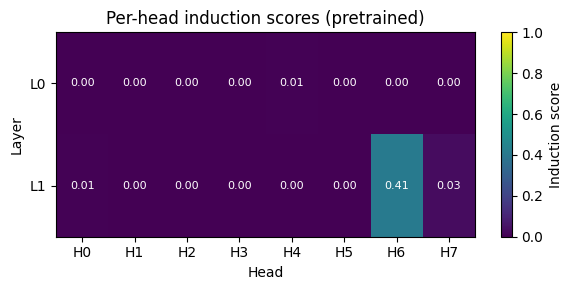

Figure 3 saved.


In [7]:
figures_dir = Path('../paper/figures'); figures_dir.mkdir(parents=True, exist_ok=True)
fig = plot_induction_score_heatmap(means.cpu().numpy(),
    title='Per-head induction scores (pretrained)',
    save_path=figures_dir / 'fig3_induction_scores_baseline')
plt.show()
print('Figure 3 saved.')